Copyright (c) Meta Platforms, Inc. and affiliates.

<a target="_blank" href="https://colab.research.google.com/github/facebookresearch/co-tracker/blob/main/notebooks/demo.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# CoTracker: It is Better to Track Together
This is a demo for <a href="https://co-tracker.github.io/">CoTracker</a>, a model that can track any point in a video.

<img src="https://www.robots.ox.ac.uk/~nikita/storage/cotracker/bmx-bumps.gif" alt="Logo" width="50%">

Don't forget to turn on GPU support if you're running this demo in Colab. 

**Runtime** -> **Change runtime type** -> **Hardware accelerator** -> **GPU**

Let's install dependencies for Colab:

In [1]:
%cd ..
%load_ext autoreload
%autoreload 2
import os
import torch

from base64 import b64encode
from cotracker.utils.visualizer import Visualizer, read_video_from_path, read_images_from_path
from IPython.display import HTML

def show_video(video_path):
    video_file = open(video_path, "r+b").read()
    video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
    return HTML(f"""<video width="1280" height="960" autoplay loop controls><source src="{video_url}"></video>""")

/opt/venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/workspaces/co-tracker


Read a video

In [2]:
asset_folder = './assets'
img_folder_name = 'maila/overlay_depth_cam'
read_start_frame = 254
read_end_frame = 318
mask_folder_name = None # 'maila/masks'

img_folder_path = os.path.join(asset_folder, img_folder_name)
if mask_folder_name is not None:
    mask_folder_path = os.path.join(asset_folder, mask_folder_name)
else:
    mask_folder_path = None


video = read_images_from_path(img_folder_path, mask_folder_path)[read_start_frame:read_end_frame]
video = torch.from_numpy(video).permute(0, 3, 1, 2)[None].float() # video should be of shape (1, B, C, H, W), with B is number of frames
print(f"Video shape after reshape: {video.shape}")

Found # files: 385
Video shape after reshape: torch.Size([1, 64, 3, 360, 640])


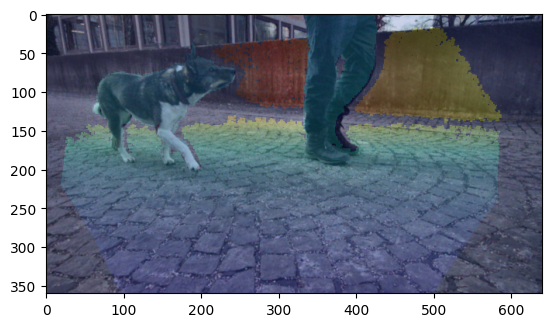

In [3]:
import time
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import torch
import numpy as np

# Squeeze the first dimension (batch size)
video_tensor = video.squeeze(0)

# Convert the tensor to numpy for matplotlib
video_tensor = video_tensor.permute(0, 2, 3, 1).numpy()  # Shape (B, H, W, C)

# Create a figure for displaying
fig, ax = plt.subplots()

# Loop through frames and display them
for frame in video_tensor[:10]:
    ax.imshow(frame.astype(np.uint8))
    display(fig)  # Display the figure in the notebook cell
    clear_output(wait=True)  # Clear the output to show the next frame
    plt.pause(0.1)  # Pause to simulate video frame display

plt.show()

Import CoTrackerPredictor and create an instance of it. We'll use this object to estimate tracks:

In [4]:
from cotracker.predictor import CoTrackerPredictor

model = CoTrackerPredictor(
    checkpoint=os.path.join(
        '/checkpoints/scaled_offline.pth'
    )
)

In [5]:
if torch.cuda.is_available():
    model = model.cuda()
    video = video.cuda()
    print("Cuda available!")

/opt/venv/lib/python3.10/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


## Tracking manually selected points

In [6]:
# From https://github.com/google-deepmind/tapnet/blob/main/tapnet/utils/viz_utils.py
# Generate random colormaps for visualizing different points.
import random
from typing import List, Optional, Sequence, Tuple
import colorsys
def get_colors(num_colors: int) -> List[Tuple[int, int, int]]:
  """Gets colormap for points."""
  colors = []
  for i in np.arange(0.0, 360.0, 360.0 / num_colors):
    hue = i / 360.0
    lightness = (50 + np.random.rand() * 10) / 100.0
    saturation = (90 + np.random.rand() * 10) / 100.0
    color = colorsys.hls_to_rgb(hue, lightness, saturation)
    colors.append(
        (int(color[0] * 255), int(color[1] * 255), int(color[2] * 255))
    )
  random.shuffle(colors)
  return colors

**If the following cell gives error like "cannot render ipy widget", do the following**

> pip install -U ipywidgets==7.7.1

> jupyter-notebook notebooks/manual_tracking.ipynb 

> Developer > Reload Window**

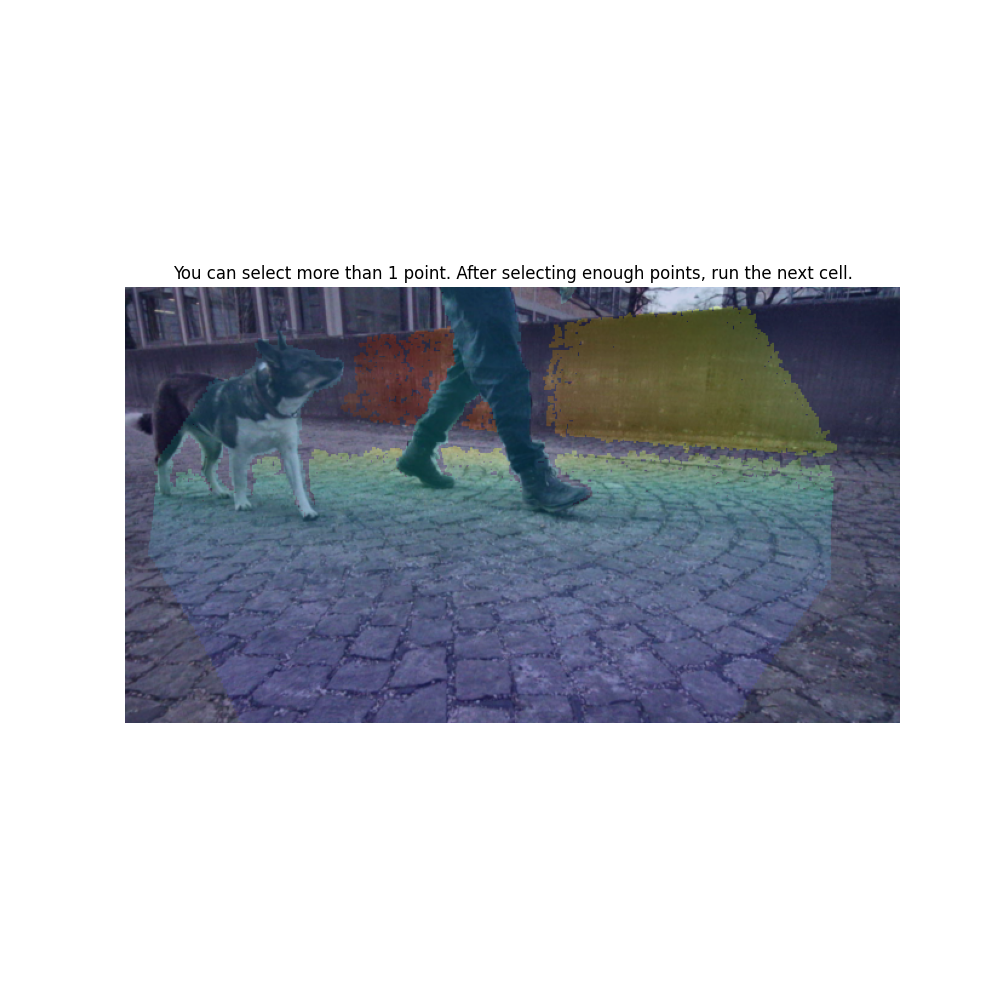

In [ ]:
%matplotlib widget
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

select_frame = 0

colormap = get_colors(50)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(video[0,select_frame,:].permute(1, 2, 0).cpu().numpy().astype(np.uint8))
ax.axis('off')
ax.set_title(
    'Hip selection order: Hind Hip, Front Hip'
)

select_points = []

# Event handler for mouse clicks
def on_click(event):
  if event.button == 1 and event.inaxes == ax:  # Left mouse button clicked
    x, y = int(np.round(event.xdata)), int(np.round(event.ydata))

    select_points.append(np.array([select_frame, x, y]))

    color = colormap[len(select_points) - 1]
    color = tuple(np.array(color) / 255.0)
    ax.plot(x, y, 'o', color=color, markersize=5)
    plt.draw()


fig.canvas.mpl_connect('button_press_event', on_click)
plt.show()

In [8]:
queries = torch.tensor(select_points, dtype=torch.float32)
if torch.cuda.is_available():
    queries = queries.cuda()
print(f"Shape of queries: {queries.shape}");



Shape of queries: torch.Size([2, 3])


/tmp/ipykernel_1512/1990165369.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  queries = torch.tensor(select_points, dtype=torch.float32)


We pass these points as input to the model and track them:

In [9]:
pred_tracks, pred_visibility = model(video, queries=queries[None], backward_tracking=True)
# TODO give mask here

Finally, we visualize the results with tracks leaving traces from the frame where the tracking starts.
Color encodes time:

In [10]:
vis = Visualizer(
    save_dir=os.path.join('./videos', img_folder_name.rsplit('.', 1)[0]),
    linewidth=6,
    mode='rainbow',
    tracks_leave_trace=0
)
vis.visualize(
    video=video,
    tracks=pred_tracks,
    visibility=pred_visibility,
    filename='queries');

video_path = os.path.join('./videos', img_folder_name.rsplit('.', 1)[0])

queries = read_video_from_path(os.path.join(video_path, "queries.mp4"))
output_folder = f"{video_path}/frames"
os.makedirs(output_folder, exist_ok=True)

# Save each frame as an RGB image
for i, frame in enumerate(queries):
    plt.imsave(os.path.join(output_folder, f"frame_{i:04d}.png"), frame)
print(f"Frames saved to {output_folder}")

# Save infos
info_file_path = os.path.join(video_path, "00_infos.txt")
with open(info_file_path, "w") as f:
    f.write(f"Selected frame: {select_frame}\n")
print(f"Info file saved to {info_file_path}")

show_video(os.path.join(video_path, "queries.mp4"))


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (640, 360) to (640, 368) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Video saved to ./videos/maila/overlay_depth_cam/queries.mp4
Frames saved to ./videos/maila/overlay_depth_cam/frames
Info file saved to ./videos/maila/overlay_depth_cam/00_infos.txt


Notice that points queried at frames 10, 20, and 30 are tracked **incorrectly** before the query frame. This is because CoTracker is an online algorithm and only tracks points in one direction. However, we can also run it backward from the queried point to track in both directions. Let's correct this:

In [11]:
# save
pred_tracks = pred_tracks.long()
print(f"shape of pred_tracks: {pred_tracks.shape}")


os.makedirs(video_path, exist_ok=True)
np.save(os.path.join(video_path, 'hip_pos.npy'), pred_tracks.cpu().numpy())



shape of pred_tracks: torch.Size([1, 64, 2, 2])
